In [1]:
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

import keras
from keras import layers
import pydot, graphviz

import pandas as pd
import numpy as np
#import matplotlib.pyplot as plt

from preprocessing_old import Preprocessor
#from model_builder import ModelBuilder
from plotting_old import Plotter

from sklearn.neural_network import MLPRegressor

#https://ipython.org/ipython-doc/3/config/extensions/autoreload.html
%load_ext autoreload
%autoreload 2

I0000 00:00:1784581787.745917    4439 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784581788.054017    4439 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784581791.378889    4439 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
#!uv pip install pydot graphviz

Using Python 3.12.3 environment at: /home/johnhas/DistSys_Project/team-red/ProcessEnergyAccounting/.venv
Checked 2 packages in 5ms


In [2]:
#These seem to generalize well to other benchmarks as well
good_features = ['delta_io_bytes', 'delta_cycles', 'delta_cpu_ns', 'delta_branch_instructions', 'syscall_class_signal']# R² 98% and 3,15% for the workflow data which is crazy

target = "interval_energy"

#DATA_PATH = "../../workflows/siena12/stressng-custom-1782744477/datasets/process_interval_data.parquet"
#DATA_PATH = "../../workflows/siena12/nfcore-20260701T215234Z/datasets/sarek_1_0207.parquet"
DATA_PATH = "../../workflows/siena12/nfcore-20260701T215234Z/datasets/sarek_1_0207.parquet"

#DATA_PATH = "../../workflows/gpu06/stressng-custom-1782751694/datasets/process_interval_data.parquet"
data = pd.read_parquet(DATA_PATH)
print("Loading data...")


Loading data...


In [3]:
data.shape

(9326973, 32)

In [3]:
preprocessor = Preprocessor(data, good_features)
X, y, times = preprocessor.preprocess()

In [4]:
full_features = ['delta_io_bytes', 'delta_cycles', 'delta_cpu_ns', 'delta_branch_instructions', 'syscall_class_signal']

X_train1, X_test1,y_train1,y_test1, t_train1, t_test1 = train_test_split(X, y, times, test_size=0.2, shuffle=False)


In [6]:
X_train1.shape

(6650, 5)

In [ ]:
# Build the 1D-CNN in Keras
#https://keras.io/guides/sequential_model/
#https://keras.io/examples/timeseries/timeseries_classification_from_scratch/
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.keras", save_best_only=True, monitor="val_loss"),
    keras.callbacks.TerminateOnNaN(),
    keras.callbacks.EarlyStopping(monitor='loss',patience=3,restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, min_lr=0.0001)
    ]
cnn_model = keras.Sequential([

    layers.Input(shape=(5, 1)), # (num_features, sequence_length)
    layers.Conv1D(32, kernel_size=5, padding='same', activation="relu"),
    layers.BatchNormalization(),

    layers.Conv1D(32, kernel_size=5, padding='same', activation="relu"),
    layers.BatchNormalization(),

    #layers.Conv1D(32, kernel_size=5, padding='same', activation="relu"),
    #layers.BatchNormalization(),
    
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
    
])
optimizer=keras.optimizers.Adam(learning_rate=0.0001, epsilon=1e-4)

cnn_model.compile(optimizer=optimizer, loss='mse',
        metrics=['mae'])

cnn_model.summary()


In [ ]:
# Standard fit function with built-in validation split
scaler = StandardScaler()
X_train_scaled1 = scaler.fit_transform(X_train1)
X_test_scaled1 = scaler.transform(X_test1)

X_train_3d = X_train_scaled1.reshape((X_train_scaled1.shape[0], X_train_scaled1.shape[1], 1))
X_test_3d = X_test_scaled1.reshape((X_test_scaled1.shape[0], X_test_scaled1.shape[1], 1))

y_train1 = y_train1.reshape(y_train1.shape[0],1)
y_test1 = y_test1.reshape(y_test1.shape[0],1)
cnn_model.fit(X_train_3d, y_train1, epochs=30, batch_size=32, validation_split=0.2)


In [62]:
# From model_builder.py
def evaluate(y_test1, y_pred1):
    r2 = r2_score(y_test1, y_pred1)
    mae = mean_absolute_error(y_test1, y_pred1)
    mean_energy = y_test1.mean()
    mae_pct = (mae / mean_energy) * 100
        
    print(" Model evaluation ")
    print(f"  R² Score:  {r2:.4f}")
    print(f"  MAE:       {mae:.2f} Wh ({mae_pct:.2f}% of mean)")
    print("-" * 34)


In [ ]:
# Validation set:
y_pred1 = cnn_model.predict(X_test_3d)
evaluate(y_test1, y_pred1)

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
 CNN 1D 
  R² Score:  0.5040
  MAE:       4.74 Wh (2.61% of mean)
----------------------------------


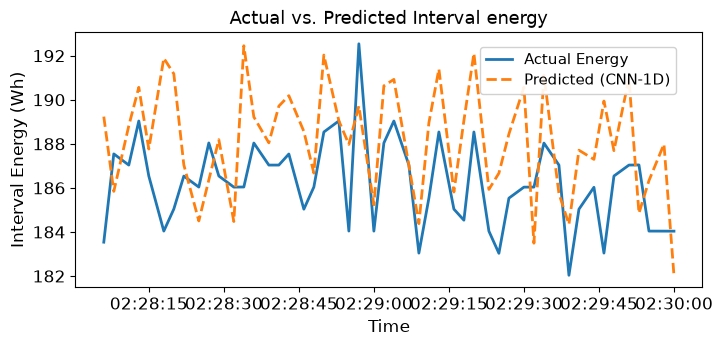

In [ ]:
plotter = Plotter(y_pred=y_pred1,y_test=y_test1, t_test= t_test1,alg_name="cnn_1d",window_start=150, window_end=200)
#plotter.plot_only("cnn_1d")
plotter.plot_and_save("cnn_1d_small_")

In [59]:
# Build the 1D-CNN in Keras
#https://keras.io/guides/sequential_model/
#https://keras.io/examples/timeseries/timeseries_classification_from_scratch/
# https://www.tensorflow.org/tutorials/structured_data/time_series#recurrent_neural_network
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.keras", save_best_only=True, monitor="val_loss"),
    keras.callbacks.TerminateOnNaN(),
    keras.callbacks.EarlyStopping(monitor='loss',patience=3,restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, min_lr=0.0001)
    ]
ffnn_model = keras.Sequential([
    layers.Input(shape=(5, 1)), # (num_features, sequence_length) 
    layers.Flatten(),
    #layers.GlobalAveragePooling1D(),
    #layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
    
])
optimizer=keras.optimizers.Adam(learning_rate=1e-3, epsilon=1e-4)

ffnn_model.compile(optimizer=optimizer, loss='mse',
        metrics=['mae'])

ffnn_model.summary()


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_17 (Flatten)            │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441 (5.63 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
# FFNN train fit
ffnn_model.fit(X_train_3d, y_train1, epochs=50, batch_size=64, validation_split=0.2)


Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 44511.4570 - mae: 208.3318 - val_loss: 33528.5859 - val_mae: 183.0845
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 40387.1406 - mae: 198.5874 - val_loss: 29564.5137 - val_mae: 171.8549
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29433.7871 - mae: 168.5243 - val_loss: 20243.3828 - val_mae: 141.9980
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15393.4541 - mae: 118.1105 - val_loss: 7146.5737 - val_mae: 84.3173
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5527.4233 - mae: 64.1458 - val_loss: 418.3556 - val_mae: 18.3454
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2327.5464 - mae: 34.3810 - val_loss: 213.0110 - val_mae: 12.8392
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1802.4938 - mae: 32.1810 - val_loss: 302.2562 - val_mae: 15.9594
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1570.0476 - mae: 30.3845 - val_loss: 301.8370 - val_mae: 16.110

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
 CNN 1D 
  R² Score:  0.4611
  MAE:       4.78 Wh (2.64% of mean)
----------------------------------


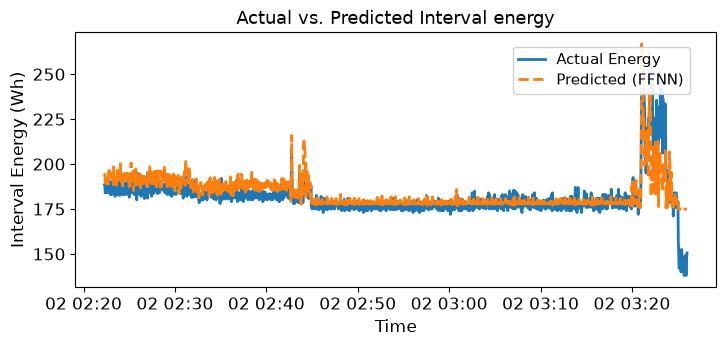

In [61]:
y_pred_ffnn = ffnn_model.predict(X_test_3d)
evaluate(y_test1, y_pred_ffnn)
plotter = Plotter(y_pred=y_pred_ffnn,y_test=y_test1, t_test= t_test1,alg_name="ffnn") #,window_start=150, window_end=200
plotter.plot_only("ffnn_")
#plotter.plot_and_save("cnn_1d_small_")

In [118]:
# Build the 1D-CNN in Keras
#https://keras.io/guides/sequential_model/
#https://keras.io/examples/timeseries/timeseries_classification_from_scratch/
# https://www.tensorflow.org/tutorials/structured_data/time_series#recurrent_neural_network
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.keras", save_best_only=True, monitor="val_loss"),
    keras.callbacks.TerminateOnNaN(),
    keras.callbacks.EarlyStopping(monitor='loss',patience=3,restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, min_lr=0.0001)
    ]
lstm_model = keras.Sequential([
    layers.Input(shape=(5, 1)), # (num_features, sequence_length)
    layers.BatchNormalization(),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(64, return_sequences=True),
    layers.Flatten(),
    #layers.GlobalAveragePooling1D(),
    #layers.Dropout(0.2),
    #layers.Dense(32, activation='relu'),
    layers.Dense(1)
    
])
optimizer=keras.optimizers.Adam(learning_rate=0.001, epsilon=1e-4)

lstm_model.compile(optimizer=optimizer, loss='mse',
        metrics=['mae'])

lstm_model.summary()


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_8           │ (None, 5, 1)           │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_47 (LSTM)                  │ (None, 5, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_48 (LSTM)                  │ (None, 5, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_38 (Flatten)            │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 1)              │           321 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,245 (196.27 KB)

 Trainable params: 50,243 (196.26 KB)

 Non-trainable params: 2 (8.00 B)

In [119]:
# LTSM train fit
lstm_model.fit(X_train_3d, y_train1, epochs=30, batch_size=64, validation_split=0.2)


Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 40795.1602 - mae: 198.8805 - val_loss: 23575.8242 - val_mae: 153.5185
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 26851.4316 - mae: 160.0262 - val_loss: 14177.2285 - val_mae: 119.0333
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 17650.5488 - mae: 128.1308 - val_loss: 7731.1611 - val_mae: 87.8699
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 10989.5391 - mae: 98.6697 - val_loss: 3634.0022 - val_mae: 60.1881
Epoch 5/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6778.0278 - mae: 74.4551 - val_loss: 1551.9238 - val_mae: 39.2613
Epoch 6/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4319.1348 - mae: 55.9289 - val_loss: 543.7786 - val_mae: 23.1103
Epoch 7/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2886.7646 - mae: 41.4898 - val_loss: 116.8385 - val_mae: 10.3771
Epoch 8/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2064.6562 - mae: 31.0287 - val_loss: 9.1651 - val_mae: 2.

In [120]:
y_pred_lstm = lstm_model.predict(X_test_3d)
evaluate(y_test1, y_pred_lstm)

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
 Model evaluation 
  R² Score:  -3.4598
  MAE:       21.85 Wh (12.05% of mean)
----------------------------------


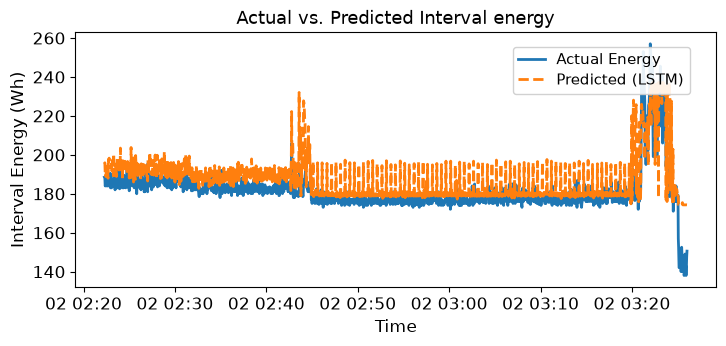

In [117]:
plotter = Plotter(y_pred=y_pred_lstm,y_test=y_test1, t_test= t_test1,alg_name="lstm") #,window_start=150, window_end=200
plotter.plot_only("lstm")
#plotter.plot_and_save("cnn_1d_small_")